Alright—let’s go beyond toy data and do a realistic, large-dataset, step-by-step Gradient Boosting workflow with proper evaluation and interpretation.

🧠 Problem: Predict House Prices (Large Dataset)

We’ll simulate a large dataset (10,000 rows) with multiple features.

🔁 Step 1: Generate Large Dataset

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "size": np.random.randint(500, 4000, n),
    "bedrooms": np.random.randint(1, 6, n),
    "age": np.random.randint(0, 30, n),
    "distance_city": np.random.randint(1, 50, n)
})

# Target (price)
data["price"] = (
    data["size"] * 0.05 +
    data["bedrooms"] * 10 -
    data["age"] * 0.8 -
    data["distance_city"] * 0.5 +
    np.random.normal(0, 10, n)
)

print(data.head())

   size  bedrooms  age  distance_city       price
0  3674         5    9             38  211.454694
1  1360         4   19             32   88.924909
2  1794         2   13             40   71.118658
3  1630         1   13             29   46.267009
4  1595         1   25              6   61.767356


In [4]:
#Step 2: Split Data
from sklearn.model_selection import train_test_split

X = data.drop("price", axis=1)
y = data["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [2]:
data.describe()

,size,bedrooms,age,distance_city,price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2259.620800,2.993300,14.337700,25.061000,118.800684
std,1011.317204,1.420161,8.597817,14.064525,54.277583
min,500.000000,1.000000,0.000000,1.000000,-14.778405
25%,1390.750000,2.000000,7.000000,13.000000,74.963355
50%,2267.000000,3.000000,14.000000,25.000000,119.277282
75%,3141.000000,4.000000,22.000000,37.000000,162.184619
max,3999.000000,5.000000,29.000000,49.000000,266.001873


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size           10000 non-null  int32  
 1   bedrooms       10000 non-null  int32  
 2   age            10000 non-null  int32  
 3   distance_city  10000 non-null  int32  
 4   price          10000 non-null  float64
dtypes: float64(1), int32(4)
memory usage: 234.5 KB


In [5]:
#Step 3: Train Gradient Boosting Model
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=200,     # more trees for large data
    learning_rate=0.05,   # smaller = better generalization
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [6]:
#Step 4: Predictions
y_pred = model.predict(X_test)

In [7]:
#Step 5: Evaluate Model
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 10.193747690675995
R2 Score: 0.9640964591842118


Interpretation:
RMSE → lower is better
R² Score → closer to 1 = better
🌳 Step 6: Feature Importance

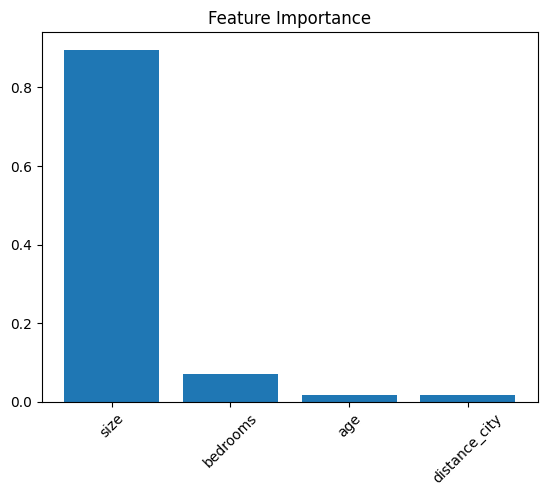

In [8]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()